# 03 - GOES Ambient Validation

## Objective

Evaluate the physical consistency of GOES-derived cloud features by comparing them against in-situ measurements recorded by the Ambient Weather station installed at the Quito Astronomical Observatory.

This validation aims to determine whether the selected GOES variables capture meaningful atmospheric conditions observed from the ground and should therefore be retained for the final forecasting dataset.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [41]:
# Definir la ruta base del proyecto usando Path
DATA_PATH = Path("../data/processed")

# Carga de datos
goes_df = pd.read_csv(DATA_PATH / "goes_features_2026_05_10.csv")
jardin_10min = pd.read_csv(DATA_PATH / "jardin_2026_05_10_10min.csv")

# Verificación de dimensiones
print(f"GOES features shape:            {goes_df.shape}")
print(f"Ambient Weather (10 min) shape: {jardin_10min.shape}")

GOES features shape:            (134, 18)
Ambient Weather (10 min) shape: (144, 2)


In [42]:
# 1. Procesamiento de tiempos de GOES (UTC -> Local -> Naive)
goes_df["timestamp"] = pd.to_datetime(goes_df["timestamp"])
goes_df["timestamp_local"] = (
    goes_df["timestamp"]
    .dt.tz_localize("UTC")
    .dt.tz_convert("America/Guayaquil")
    .dt.tz_localize(None)  # Forzar a 'naive' para que coincida con la estación
)
goes_df["time_10min"] = goes_df["timestamp_local"].dt.floor("10min")

# 2. Procesamiento de tiempos de la estación meteorológica
jardin_10min["time_10min"] = pd.to_datetime(jardin_10min["time_10min"])

In [56]:
# Verificar rangos temporales
print(f"Rango temporal GOES:    {goes_df['timestamp_local'].min()} a {goes_df['timestamp_local'].max()}")
print(f"Rango temporal Estación: {jardin_10min['time_10min'].min()} a {jardin_10min['time_10min'].max()}\n")

# Calcular escenas faltantes
goes_times = set(goes_df["time_10min"])
ambient_times = set(jardin_10min["time_10min"])
missing = sorted(list(ambient_times - goes_times))

print(f"Escenas GOES faltantes respecto a la estación: {len(missing)}")
if missing:
    print("Primeras 5 marcas de tiempo faltantes en GOES:")
    for t in missing[:5]:
        print(f"  - {t}")

Rango temporal GOES:    2026-05-09 20:45:07.820574976 a 2026-05-10 18:55:08.589005056
Rango temporal Estación: 2026-05-10 00:00:00 a 2026-05-10 23:50:00

Escenas GOES faltantes respecto a la estación: 30
Primeras 5 marcas de tiempo faltantes en GOES:
  - 2026-05-10 19:00:00
  - 2026-05-10 19:10:00
  - 2026-05-10 19:20:00
  - 2026-05-10 19:30:00
  - 2026-05-10 19:40:00


In [45]:
# 1. Asegurar que ambas columnas sean 'naive' (sin zona horaria explícita) para evitar el conflicto
if hasattr(goes_df["time_10min"].dtype, "tz") and goes_df["time_10min"].dtype.tz is not None:
    goes_df["time_10min"] = goes_df["time_10min"].dt.tz_localize(None)

if hasattr(jardin_10min["time_10min"].dtype, "tz") and jardin_10min["time_10min"].dtype.tz is not None:
    jardin_10min["time_10min"] = jardin_10min["time_10min"].dt.tz_localize(None)

# 2. Fusionar datasets por la ventana común de 10 minutos (Sincronización OAQ - GOES)
fusion_df = pd.merge(goes_df, jardin_10min, on="time_10min", how="inner")

# 3. Diagnóstico del cruce
print(f"Dimensiones del dataset fusionado: {fusion_df.shape}")
print(f"Rango temporal del cruce:          {fusion_df['time_10min'].min()} a {fusion_df['time_10min'].max()}")

Dimensiones del dataset fusionado: (114, 19)
Rango temporal del cruce:          2026-05-10 00:00:00 a 2026-05-10 18:50:00


In [46]:
# Columnas seleccionadas para la validación física de nubosidad
features_interes = [
    "time_10min",
    "solar_radiation",
    "cmi_c13_mean",
    "cmi_c13_std",
    "btd_13_15",
    "btd_13_16"
]

fusion_df[features_interes].head()

,time_10min,solar_radiation,cmi_c13_mean,cmi_c13_std,btd_13_15,btd_13_16
0,2026-05-10 00:00:00,0.0,276.600342,2.558516,5.493317,17.640045
1,2026-05-10 00:10:00,0.0,275.865356,2.397893,7.176514,18.782257
2,2026-05-10 00:20:00,0.0,275.860443,2.336130,5.949432,17.755005
3,2026-05-10 00:30:00,0.0,275.978424,2.162956,4.011353,16.229370
4,2026-05-10 00:40:00,0.0,275.484344,2.864813,2.466644,14.721771


In [47]:
# Filtrado diurno: Se aíslan las horas de luz (Radiación > 20 W/m²) 
# para que el proxy de nubosidad sea físicamente válido.
day_df = fusion_df[fusion_df["solar_radiation"] > 20].copy()

print(f"Registros diurnos resultantes: {day_df.shape[0]} (de {fusion_df.shape[0]} totales)")

Registros diurnos resultantes: 66 (de 114 totales)


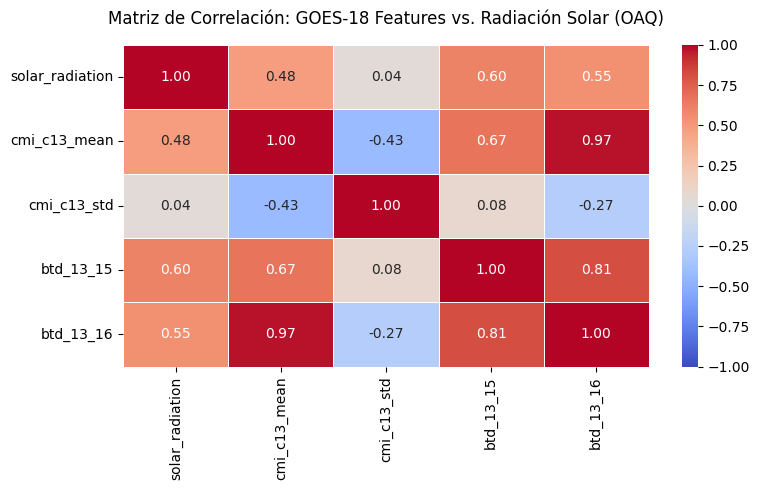

,solar_radiation,cmi_c13_mean,cmi_c13_std,btd_13_15,btd_13_16
solar_radiation,1.000000,0.479443,0.039014,0.603128,0.545547
cmi_c13_mean,0.479443,1.000000,-0.426487,0.666234,0.971198
cmi_c13_std,0.039014,-0.426487,1.000000,0.081594,-0.266360
btd_13_15,0.603128,0.666234,0.081594,1.000000,0.813275
btd_13_16,0.545547,0.971198,-0.266360,0.813275,1.000000


In [48]:
# Variables clave para la validación de nubosidad
cols_validacion = [
    "solar_radiation",
    "cmi_c13_mean",
    "cmi_c13_std",
    "btd_13_15",
    "btd_13_16"
]

# Calcular matriz de correlación (Pearson)
corr_matrix = day_df[cols_validacion].corr()

# Visualización estandarizada
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Matriz de Correlación: GOES-18 Features vs. Radiación Solar (OAQ)", fontsize=12, pad=15)
plt.tight_layout()
plt.show()

# Mostrar la matriz numérica abajo 
corr_matrix

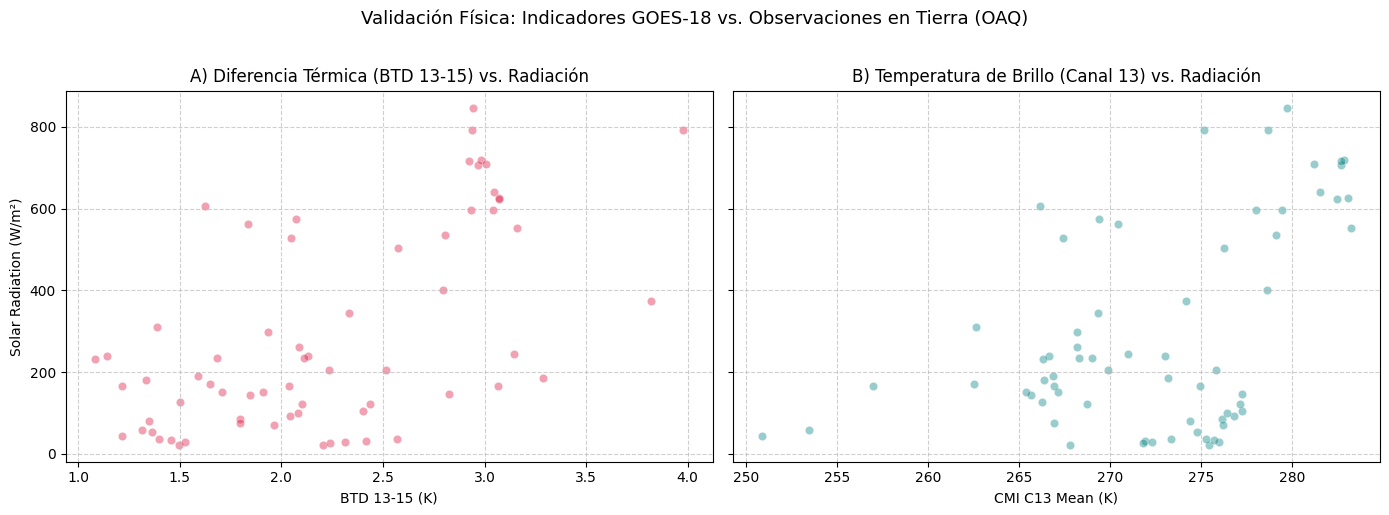

In [49]:
# Crear figura con dos subplots en paralelo compartiendo el eje Y
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# 1. Gráfico de dispersión: BTD 13-15 vs Radiación Solar
sns.scatterplot(
    data=day_df, x="btd_13_15", y="solar_radiation", 
    alpha=0.4, color="crimson", ax=axes[0]
)
axes[0].set_title("A) Diferencia Térmica (BTD 13-15) vs. Radiación")
axes[0].set_xlabel("BTD 13-15 (K)")
axes[0].set_ylabel("Solar Radiation (W/m²)")
axes[0].grid(True, linestyle="--", alpha=0.6)

# 2. Gráfico de dispersión: CMI C13 Mean vs Radiación Solar
sns.scatterplot(
    data=day_df, x="cmi_c13_mean", y="solar_radiation", 
    alpha=0.4, color="teal", ax=axes[1]
)
axes[1].set_title("B) Temperatura de Brillo (Canal 13) vs. Radiación")
axes[1].set_xlabel("CMI C13 Mean (K)")
axes[1].set_ylabel("")  # Oculto porque comparte el eje Y con el gráfico A
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Validación Física: Indicadores GOES-18 vs. Observaciones en Tierra (OAQ)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Correlación de Spearman

In [50]:
from scipy.stats import pearsonr, spearmanr

variables = ["cmi_c13_mean", "cmi_c13_std", "btd_13_15", "btd_13_16"]
stats_summary = []

for var in variables:
    r, p_r = pearsonr(day_df[var], day_df["solar_radiation"])
    rho, p_rho = spearmanr(day_df[var], day_df["solar_radiation"])
    
    stats_summary.append({
        "Variable GOES": var,
        "Pearson r": r,
        "Pearson p-value": p_r,
        "Spearman rho": rho,
        "Spearman p-value": p_rho
    })

# Convertir a DataFrame para una visualización impecable
df_correlaciones = pd.DataFrame(stats_summary).set_index("Variable GOES")
df_correlaciones.style.format({
    "Pearson r": "{:.3f}", 
    "Pearson p-value": "{:.3e}", 
    "Spearman rho": "{:.3f}", 
    "Spearman p-value": "{:.3e}"
})

,Pearson r,Pearson p-value,Spearman rho,Spearman p-value
Variable GOES,,,,
cmi_c13_mean,0.479,4.642e-05,0.361,2.930e-03
cmi_c13_std,0.039,7.558e-01,0.143,2.527e-01
btd_13_15,0.603,8.350e-08,0.530,4.624e-06
btd_13_16,0.546,2.169e-06,0.420,4.423e-04


# Transformaciones de Solar Radiation

In [51]:
# Aplicar transformaciones al proxy de radiación
day_df["solar_sqrt"] = np.sqrt(day_df["solar_radiation"])
day_df["solar_log"] = np.log1p(day_df["solar_radiation"])

targets = ["solar_radiation", "solar_sqrt", "solar_log"]
trans_results = {}

# Construir la matriz de comparación
for target in targets:
    trans_results[target] = [pearsonr(day_df[var], day_df[target])[0] for var in variables]

df_transformaciones = pd.DataFrame(trans_results, index=variables)
print("Matriz de comparación: Coeficientes Pearson r según transformación del Target:")
df_transformaciones.round(3)

Matriz de comparación: Coeficientes Pearson r según transformación del Target:


,solar_radiation,solar_sqrt,solar_log
cmi_c13_mean,0.479,0.423,0.334
cmi_c13_std,0.039,0.035,0.026
btd_13_15,0.603,0.581,0.523
btd_13_16,0.546,0.491,0.400


# Influencia de los outliers

In [52]:
# 1. Identificar e inspeccionar los 5 registros con mayor radiación solar
top_outliers = day_df.nlargest(5, "solar_radiation")[
    ["time_10min", "solar_radiation", "cmi_c13_mean", "btd_13_15", "btd_13_16"]
]
print("Top 5 registros con máxima Radiación Solar (Inspección de posibles anomalías):")
display(top_outliers)

# 2. Remover los 2 valores más extremos usando sus índices directamente
day_df_no_out = day_df.drop(top_outliers.index[:2])

# 3. Cuantificar el impacto del filtrado en la correlación de Pearson
print("\nImpacto en Pearson r tras remover los 2 outliers más altos:")
for var in variables:
    r_antes = pearsonr(day_df[var], day_df["solar_radiation"])[0]
    r_despues = pearsonr(day_df_no_out[var], day_df_no_out["solar_radiation"])[0]
    delta = r_despues - r_antes
    print(f"{var:15s} -> Antes: {r_antes:.3f} | Después: {r_despues:.3f} | Cambio: {delta:+.3f}")

Top 5 registros con máxima Radiación Solar (Inspección de posibles anomalías):


,time_10min,solar_radiation,cmi_c13_mean,btd_13_15,btd_13_16
65,2026-05-10 10:50:00,846.930,279.724640,2.942657,16.617798
66,2026-05-10 11:00:00,792.310,278.667603,2.938690,16.168854
85,2026-05-10 14:10:00,791.455,275.159882,3.979034,16.397858
59,2026-05-10 09:50:00,719.640,282.821869,2.980865,18.029572
60,2026-05-10 10:00:00,717.010,282.635040,2.922699,17.899994



Impacto en Pearson r tras remover los 2 outliers más altos:
cmi_c13_mean    -> Antes: 0.479 | Después: 0.453 | Cambio: -0.026
cmi_c13_std     -> Antes: 0.039 | Después: 0.067 | Cambio: +0.028
btd_13_15       -> Antes: 0.603 | Después: 0.587 | Cambio: -0.016
btd_13_16       -> Antes: 0.546 | Después: 0.524 | Cambio: -0.021


In [21]:
day_df.nlargest(
    5,
    "solar_radiation"
)[
    [
        "time_10min",
        "solar_radiation",
        "cmi_c13_mean",
        "btd_13_15",
        "btd_13_16"
    ]
]

,time_10min,solar_radiation,cmi_c13_mean,btd_13_15,btd_13_16
65,2026-05-10 10:50:00-05:00,846.930,279.724640,2.942657,16.617798
66,2026-05-10 11:00:00-05:00,792.310,278.667603,2.938690,16.168854
85,2026-05-10 14:10:00-05:00,791.455,275.159882,3.979034,16.397858
59,2026-05-10 09:50:00-05:00,719.640,282.821869,2.980865,18.029572
60,2026-05-10 10:00:00-05:00,717.010,282.635040,2.922699,17.899994


      MÉTRICAS DE REGRESIÓN LINEAL       
Pendiente (Slope):   214.5370
Intercepto:          -185.5068
R (Pearson):         0.6031
R² (Explicatividad): 0.3638
p-value:             8.350e-08



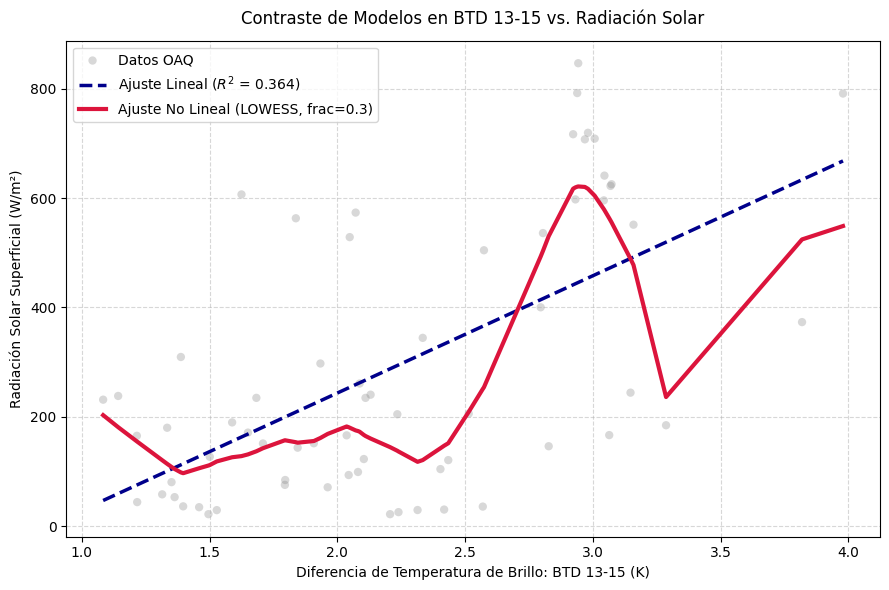

In [53]:
from scipy.stats import linregress
from statsmodels.nonparametric.smoothers_lowess import lowess

# 1. Definición de variables clave
x = day_df["btd_13_15"]
y = day_df["solar_radiation"]

# 2. Modelado Estadístico
# Ajuste Lineal
res_lineal = linregress(x, y)
# Ajuste No Lineal (LOWESS)
lowess_fit = lowess(y, x, frac=0.3)

# 3. Reporte de Métricas del Modelo Lineal
print("=========================================")
print("      MÉTRICAS DE REGRESIÓN LINEAL       ")
print("=========================================")
print(f"Pendiente (Slope):   {res_lineal.slope:.4f}")
print(f"Intercepto:          {res_lineal.intercept:.4f}")
print(f"R (Pearson):         {res_lineal.rvalue:.4f}")
print(f"R² (Explicatividad): {res_lineal.rvalue**2:.4f}")
print(f"p-value:             {res_lineal.pvalue:.3e}\n")

# 4. Visualización Comparativa Unificada
plt.figure(figsize=(9, 6))

# Gráfico de dispersión base (puntos grisáceos para resaltar los modelos)
plt.scatter(x, y, alpha=0.3, color="gray", edgecolors="none", label="Datos OAQ")

# Línea de Ajuste Lineal
x_lineal = np.linspace(x.min(), x.max(), 100)
plt.plot(
    x_lineal, 
    res_lineal.intercept + res_lineal.slope * x_lineal,
    color="darkblue", linestyle="--", linewidth=2.5,
    label=f"Ajuste Lineal ($R^2$ = {res_lineal.rvalue**2:.3f})"
)

# Curva LOWESS (No Lineal)
# statsmodels devuelve los valores ordenados por X, listos para graficar
plt.plot(
    lowess_fit[:, 0], lowess_fit[:, 1],
    color="crimson", linewidth=3,
    label="Ajuste No Lineal (LOWESS, frac=0.3)"
)

# Ajustes estéticos del gráfico
plt.title("Contraste de Modelos en BTD 13-15 vs. Radiación Solar", fontsize=12, pad=12)
plt.xlabel("Diferencia de Temperatura de Brillo: BTD 13-15 (K)", fontsize=10)
plt.ylabel("Radiación Solar Superficial (W/m²)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", frameon=True)
plt.tight_layout()

plt.show()

In [54]:
# 1. Construcción del DataFrame LOWESS (los puntos ya vienen ordenados por el scatter smoother)
lowess_df = pd.DataFrame({
    "x": lowess_fit[:, 0],
    "y_lowess": lowess_fit[:, 1]
})

# 2. Cálculo de la pendiente local (Gradiente numérico dy/dx)
lowess_df["slope"] = np.gradient(lowess_df["y_lowess"], lowess_df["x"])

# 3. Métricas de variación de la pendiente
slope_stats = lowess_df["slope"].describe()
slope_range = slope_stats["max"] - slope_stats["min"]
variacion_relativa = slope_range / abs(slope_stats["mean"])

print("==================================================")
print("     ANÁLISIS DE LA PENDIENTE LOCAL (LOWESS)      ")
print("==================================================")
print(f"Variación Relativa de la Pendiente: {variacion_relativa:.4f}")
print("\nEstadísticos descriptivos de la pendiente local:")
print(slope_stats.round(4).to_string())

     ANÁLISIS DE LA PENDIENTE LOCAL (LOWESS)      
Variación Relativa de la Pendiente: 37.2763

Estadísticos descriptivos de la pendiente local:
count      66.0000
mean      -69.2904
std       489.8438
min     -1424.2957
25%      -319.3454
50%      -119.3502
75%       196.7761
max      1158.5931


In [55]:
from sklearn.metrics import r2_score

# 1. Calcular la referencia lineal teórica sobre el eje X del LOWESS
lowess_df["y_linear"] = res_lineal.intercept + res_lineal.slope * lowess_df["x"]
lowess_df["difference"] = lowess_df["y_lowess"] - lowess_df["y_linear"]

# 2. Mapear (interpolar) el ajuste suavizado a los datos originales para evaluar el R² real
y_pred_linear = res_lineal.intercept + res_lineal.slope * x
y_pred_lowess = np.interp(x, lowess_df["x"], lowess_df["y_lowess"])

r2_linear = r2_score(y, y_pred_linear)
r2_lowess = r2_score(y, y_pred_lowess)

print("==================================================")
print("   COMPARACIÓN DE RENDIMIENTO: LINEAL VS LOWESS   ")
print("==================================================")
print(f"R² Modelo Lineal:                {r2_linear:.4f}")
print(f"R² Modelo LOWESS:                {r2_lowess:.4f}")
print(f"Ganancia neta de varianza expl.:  {r2_lowess - r2_linear:+.4f}")
print("--------------------------------------------------")
print(f"Máxima divergencia absoluta entre modelos: {lowess_df['difference'].abs().max():.2f} W/m²")
print("\nDistribución de las diferencias (LOWESS - Lineal):")
print(lowess_df["difference"].describe().round(2).to_string())

   COMPARACIÓN DE RENDIMIENTO: LINEAL VS LOWESS   
R² Modelo Lineal:                0.3638
R² Modelo LOWESS:                0.5740
Ganancia neta de varianza expl.:  +0.2102
--------------------------------------------------
Máxima divergencia absoluta entre modelos: 283.37 W/m²

Distribución de las diferencias (LOWESS - Lineal):
count     66.00
mean     -20.92
std      111.16
min     -283.37
25%      -96.62
50%      -36.10
75%       79.67
max      176.33


In [57]:
# 1. Clasificación operativa del estado del cielo (Proxy: Radiación > 500 W/m²)
day_df["sky_condition"] = np.where(day_df["solar_radiation"] > 500, "Clear", "Cloudy")

# 2. Resumen estadístico de BTD 13-15 según la condición del cielo
summary_stats = day_df.groupby("sky_condition")["btd_13_15"].describe()

print("=========================================================")
print("  ESTADÍSTICOS DESCRIPTIVOS DE BTD 13-15 POR CONDICIÓN   ")
print("=========================================================")
display(summary_stats.round(3))

  ESTADÍSTICOS DESCRIPTIVOS DE BTD 13-15 POR CONDICIÓN   


,count,mean,std,min,25%,50%,75%,max
sky_condition,,,,,,,,
Clear,19.0,2.791,0.548,1.625,2.689,2.943,3.044,3.979
Cloudy,47.0,1.997,0.611,1.083,1.498,1.962,2.324,3.819


In [58]:
from scipy.stats import ttest_ind

# Slicing único de los subconjuntos de interés
clear_btd = day_df.loc[day_df["sky_condition"] == "Clear", "btd_13_15"]
cloudy_btd = day_df.loc[day_df["sky_condition"] == "Cloudy", "btd_13_15"]

# 1. Prueba de Hipótesis: t-test de Welch (varianzas no asumidas como iguales)
t_stat, p_val = ttest_ind(clear_btd, cloudy_btd, equal_var=False)

# 2. Tamaño del Efecto: d de Cohen (Cálculo robusto ponderado)
n1, n2 = len(clear_btd), len(cloudy_btd)
s1, s2 = clear_btd.std(), cloudy_btd.std()

pooled_std = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
cohens_d = (clear_btd.mean() - cloudy_btd.mean()) / pooled_std

# 3. Reporte de Resultados
print("=========================================================")
print("      VALIDACIÓN DE CAPACIDAD DE DISCRIMINACIÓN         ")
print("=========================================================")
print(f"t-statistic (Welch):  {t_stat:.4f}")
print(f"p-value:              {p_val:.3e}")
print(f"d de Cohen:           {cohens_d:.4f}")
print("---------------------------------------------------------")

# Interpretación científica automática de la magnitud del efecto
abs_d = abs(cohens_d)
if abs_d > 0.8:
    interpretacion = "Muy Alta (Efecto Grande)"
elif abs_d > 0.5:
    interpretacion = "Moderada (Efecto Mediano)"
elif abs_d > 0.2:
    interpretacion = "Baja (Efecto Pequeño)"
else:
    interpretacion = "Despreciable"

print(f"Capacidad de separación física de la característica: {interpretacion}")

      VALIDACIÓN DE CAPACIDAD DE DISCRIMINACIÓN         
t-statistic (Welch):  5.1480
p-value:              8.951e-06
d de Cohen:           1.3362
---------------------------------------------------------
Capacidad de separación física de la característica: Muy Alta (Efecto Grande)
